In [125]:
rds <- readRDS('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/Ru_plots/leafcutter2_fig4a_qqplot_eQTL.rds')

In [1]:
library(ggplot2)
library(dplyr)
library(tidyverse)
library(ggrastr)
library(foreach)

multiqq=function(pvalues) {
  punif=-log10(runif(max(sapply(pvalues,length)))) #  a vector of randomly generated values, with the length equal to the length of the longest p-value vector
  df=do.call(rbind, foreach( i=seq_len(length(pvalues))) %do%  {
    df=as.data.frame( qqplot(punif[1:length(pvalues[[i]])], -log10(pvalues[[i]]), plot.it=F) )
    df$group=names(pvalues)[i]
    df
  } )
  df$group=factor(df$group, names(pvalues))
  ggplot(df, aes(x,y,col=group)) + geom_point_rast() + geom_abline(intercept=0,slope=1) + theme_bw(base_size=18) + xlab("Expected -log10(p)") + ylab("Observed -log10(p)")
}


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"'timedatectl' indicates the non-existent timezone name 'n/a'"
unable to deduce timezone name from 'America/Chicago'

-- Attaching packages ------------------------------------------------------------------------------------------------------------------------------------------------------ tidyverse 1.3.1 --

v tibble  3.2.1     v purrr   1.0.2
v tidyr   1.3.1     v stringr 1.5.1
v readr   1.4.0     v forcats 0.5.1

-- Conflicts --------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()


Attaching package: 'foreach'


The following objects are masked from 'package:purrr':

    

In [127]:
up_palette <- c("#1f77b4", "#d62728")

In [128]:
set.seed(0)
qq_plot <- multiqq(
  list(`p-sQTL` = rds$eqtl_lf2_pro[, 'pvalue'],
       `u-sQTL` = rds$eqtl_lf2_unpro[, 'pvalue']      
      )) +
    theme(legend.title = element_blank(),
          legend.position = c(0.25, 0.6)) +
    scale_color_manual(values = up_palette) +
    theme_classic() + geom_point_rast(size = 2) +  # Adjust dot size
  theme_classic(base_size = 8) +
  theme(
    legend.title = element_blank(),
    legend.text = element_text(size = 8),
    legend.position = c(0.25, 0.6),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 8),
      
    axis.ticks.length = unit(0.15, "cm"), # Make ticks longer
      aspect.ratio = 1
  ) 

In [129]:
ggsave("../code/plots/Fig5/Fig5A-left.svg", qq_plot, width = 3, height = 3, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5A-left.pdf", qq_plot, width = 3, height = 3, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5A-left.png", qq_plot, width = 3, height = 3, units = "in", dpi = 300)

In [130]:
rds <- readRDS('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/Ru_plots/leafcutter2_fig4a_qqplot_pQTL.rds')

In [131]:
set.seed(3)
qq_plot <- multiqq(
  list(`p-sQTL` = rds$pQTL_lf2_pro[, 'pvalue'],
       `u-sQTL` = rds$pQTL_lf2_unpro[, 'pvalue']      
      )) +
    theme(legend.title = element_blank(),
          legend.position = c(0.25, 0.6)) +
    scale_color_manual(values = up_palette) +
    theme_classic() + geom_point_rast(size = 2) +  # Adjust dot size
  theme_classic(base_size = 8) +
  theme(
    legend.title = element_blank(),
    legend.text = element_text(size = 8),
    legend.position = c(0.25, 0.6),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 8),
      
    axis.ticks.length = unit(0.15, "cm"), # Make ticks longer
      aspect.ratio = 1
  ) 

In [132]:
ggsave("../code/plots/Fig5/Fig5A-right.svg", qq_plot, width = 3, height = 3, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5A-right.pdf", qq_plot, width = 3, height = 3, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5A-right.png", qq_plot, width = 3, height = 3, units = "in", dpi = 300)

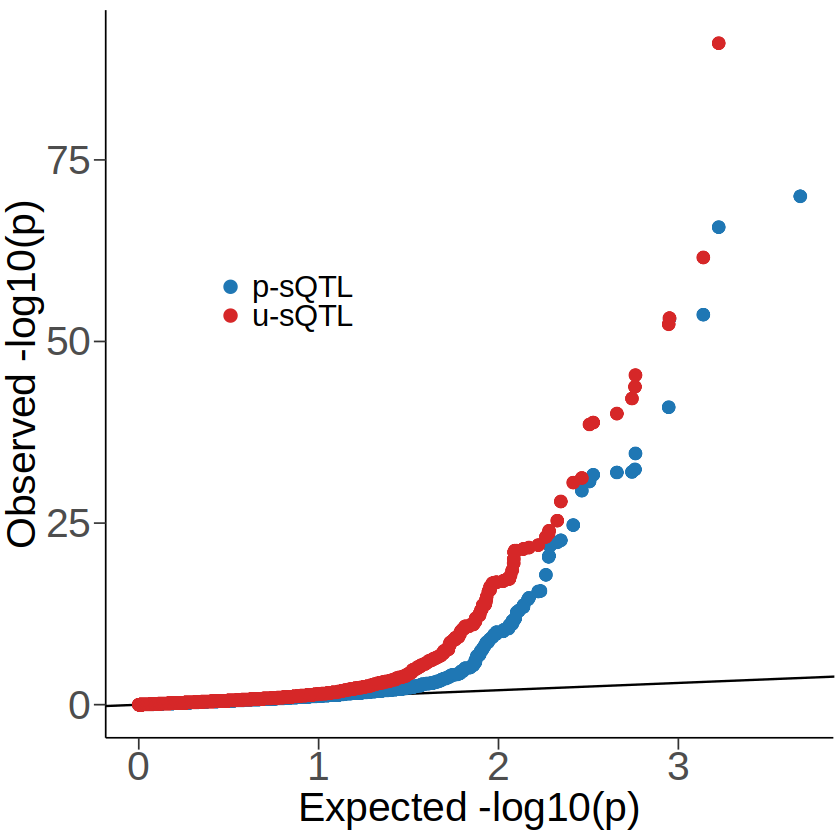

In [111]:
qq_plot

In [2]:
ptwas_results_new <- readRDS('../code/Ru_plots/leafcutter2_fig4b.ptwas_new.rds')

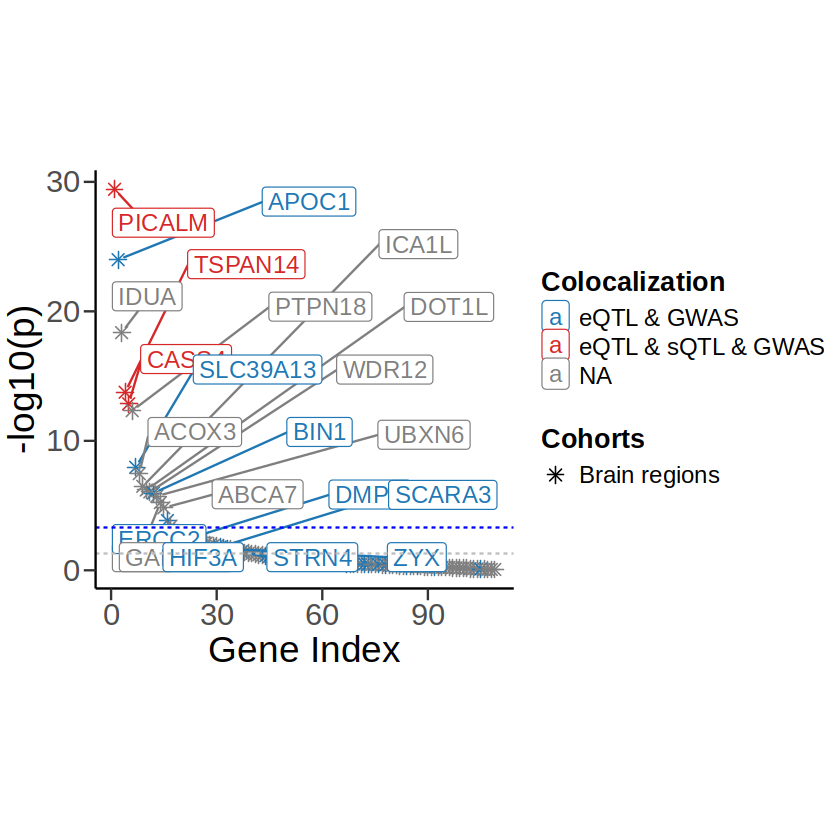

In [3]:
library(ggplot2)
library(dplyr)
library(ggrepel)
# Calculate the significance thresholds
threshold_high <- -log10(0.05 / nrow(ptwas_results_new))
threshold_low <- -log10(0.05)
# Define more appealing colors
color_palette <- c("#1f77b4", "#d62728", "#7f7f7f")




# Generate the plot
ptwas_plot <- ggplot(ptwas_results_new, aes(x = seq_along(PVAL), y = -log10(PVAL))) +
    geom_point(aes(color = coloc, shape = 'Brain regions', fill = coloc), size = 3) +
    geom_label_repel( # change to geom_label_repel if want to add box
        data = ptwas_results_new %>% as.data.frame() %>%
            mutate(gene_index = row_number()) %>% # Create a consistent index for x-axis
            filter(-log10(PVAL) > threshold_low & (-log10(PVAL) > threshold_high | coloc != "no colocalization")),
        aes(x = gene_index, y = -log10(PVAL), label = gene_name, color = coloc), # Use consistent x-axis index
        box.padding = 0.7,
        point.padding = 0.4,
        size = 5,
        max.overlaps = Inf, force = 20, force_pull = 20
    ) +
    geom_hline(yintercept = threshold_high, color = "blue", linetype = "dashed") +
    geom_hline(yintercept = threshold_low, color = "grey", linetype = "dashed") +
    scale_color_manual(values = color_palette) +
    scale_fill_manual(values = color_palette) + # Ensure fill colors are specified
    scale_shape_manual(values = c(8, 17, 16, 15, 2, 0, 5)) + # One noticeable shape, three filled, three hollow
    labs(
        x = "Gene Index",
        y = "-log10(p)",
        color = "Colocalization",
        fill = "Colocalization",
        shape = "Cohorts"
    ) +
    theme_classic() +
    theme(
        text = element_text(size = 18),
        axis.title = element_text(size = 22),
        axis.text = element_text(size = 18),
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        aspect.ratio = 1,
        axis.ticks.length = unit(0.25, "cm")
    )
# Print the plot
print(ptwas_plot)

ggsave("../code/plots/Fig5/Fig5C.svg", ptwas_plot, width = 9, height = 9, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5C.pdf", ptwas_plot, width = 9, height = 9, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5C.png", ptwas_plot, width = 9, height = 9, units = "in", dpi = 300)

In [4]:
ptwas_results_new

ptwas_results_new <- ptwas_results_new %>%
  mutate(coloc = ifelse(is.na(coloc), "no colocalization", coloc))

gene_id,Brain regions,PVAL,coloc,gene_name
<chr>,<fct>,<dbl>,<chr>,<chr>
ENSG00000073921,"AC,DLPFC,PCC",3.746500e-30,eQTL & sQTL & GWAS,PICALM
ENSG00000130208,"AC,DLPFC,PCC",1.023921e-24,eQTL & GWAS,APOC1
ENSG00000127415,"AC,DLPFC,PCC",4.405840e-19,NA,IDUA
ENSG00000108219,"AC,DLPFC,PCC",1.767843e-14,eQTL & sQTL & GWAS,TSPAN14
ENSG00000087589,AC,1.389878e-13,eQTL & sQTL & GWAS,CASS4
ENSG00000072135,"AC,DLPFC,PCC",4.701257e-13,NA,PTPN18
ENSG00000165915,DLPFC,1.105995e-08,eQTL & GWAS,SLC39A13
ENSG00000087008,"AC,DLPFC",3.452958e-08,NA,ACOX3
ENSG00000163596,"AC,DLPFC,PCC",3.234692e-07,NA,ICA1L


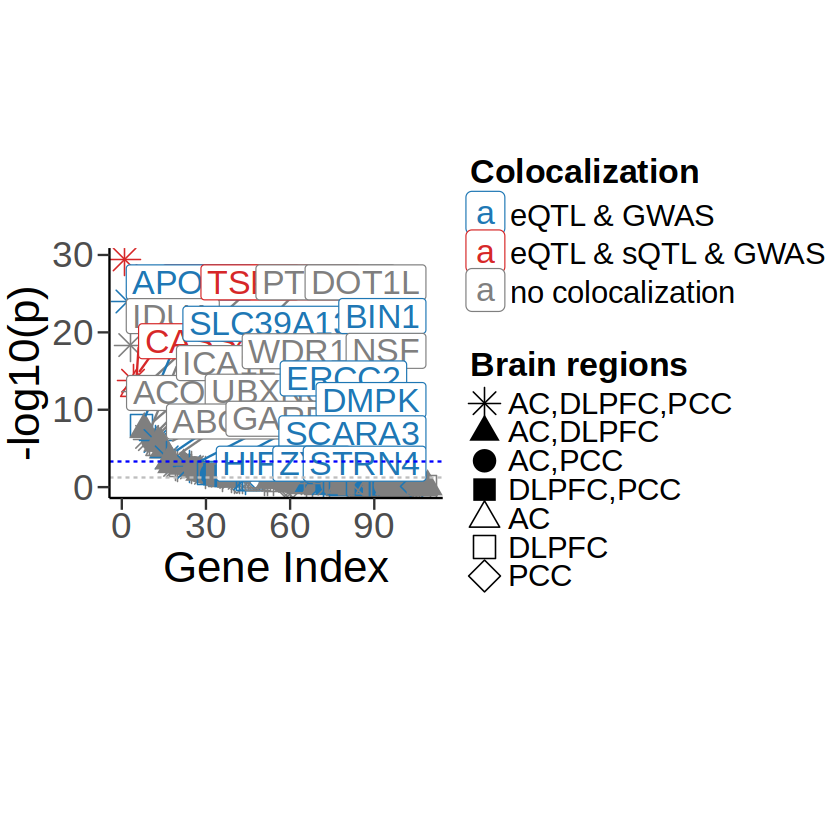

In [5]:
library(ggplot2)
library(dplyr)
library(ggrepel)
# Calculate the significance thresholds
threshold_high <- -log10(0.05 / nrow(ptwas_results_new))
threshold_low <- -log10(0.05)
# Define more appealing colors
color_palette <- c("#1f77b4", "#d62728", "#7f7f7f")




# Generate the plot
ptwas_plot <- ggplot(ptwas_results_new, aes(x = seq_along(PVAL), y = -log10(PVAL))) +
    geom_point(aes(color = coloc, shape = `Brain regions`, fill = coloc), size = 6) +
    geom_label_repel( # change to geom_label_repel if want to add box
        data = ptwas_results_new %>% as.data.frame() %>%
            mutate(gene_index = row_number()) %>% # Create a consistent index for x-axis
            filter(-log10(PVAL) > threshold_low & (-log10(PVAL) > threshold_high | coloc != "no colocalization")),
        aes(x = gene_index, y = -log10(PVAL), label = gene_name, color = coloc), # Use consistent x-axis index
        box.padding = 0.7,
        point.padding = 1,
        size = 7,
        max.overlaps = Inf, force = 40, force_pull = 20
    ) +
    geom_hline(yintercept = threshold_high, color = "blue", linetype = "dashed") +
    geom_hline(yintercept = threshold_low, color = "grey", linetype = "dashed") +
    scale_color_manual(values = color_palette) +
    scale_fill_manual(values = color_palette) + # Ensure fill colors are specified
    scale_shape_manual(values = c(8, 17, 16, 15, 2, 0, 5)) + # One noticeable shape, three filled, three hollow
    labs(
        x = "Gene Index",
        y = "-log10(p)",
        color = "Colocalization",
        fill = "Colocalization",
        shape = "Brain regions"
    ) +
    theme_classic() +
    theme(
        text = element_text(size = 26),
        axis.title = element_text(size = 26),
        axis.text = element_text(size = 22),
        legend.title = element_text(size = 20, face = "bold"),
        legend.text = element_text(size = 18),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        aspect.ratio = 0.75,
        axis.ticks.length = unit(0.25, "cm")
    )
# Print the plot
print(ptwas_plot)

ggsave("../code/plots/Fig5/Fig5C_wide.svg", ptwas_plot, width = 14, height = 9, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5C_wide.pdf", ptwas_plot, width = 14, height = 9, units = "in", dpi = 300)
ggsave("../code/plots/Fig5/Fig5C_wide.png", ptwas_plot, width = 14, height = 9, units = "in", dpi = 300)

In [19]:
df <- readRDS('../code/Ru_plots/leafcutter2_fig4e_right.tspan14.25Mar.rds')

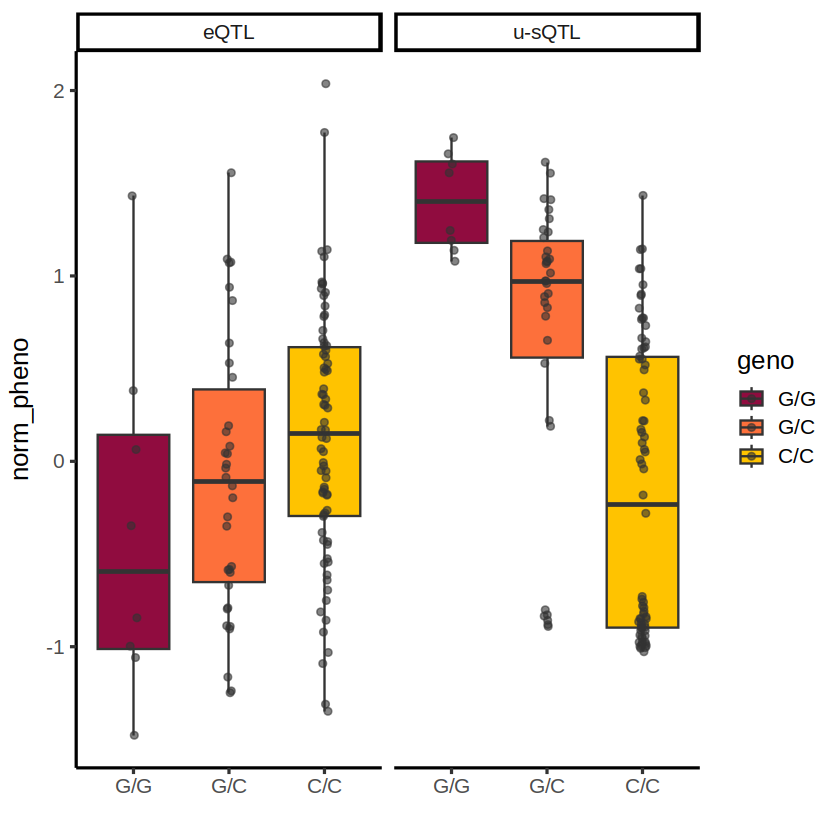

In [21]:
input_type <- "norm_pheno"
analysis_level <- "intron"

p <- ggplot(data = df, aes(x = geno, y = value, group = geno, fill = geno)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2), size = 1.5, alpha = 0.6, color = "grey20") +
    theme_classic(base_size = 15) +
    theme(
        axis.title.y = element_text(angle = 90, vjust = 1.5),
        axis.title.x = element_text(vjust = -0.5),
        plot.title = element_text(hjust = 0)
    ) +
    scale_fill_manual(values = c("#900C3F", "#FD703B", "#FFC300")) +
    scale_color_manual(values = c("#581845", "#CD5D21", "#D09E17")) +
    ylab(ifelse(analysis_level == "cluster", analysis_level, input_type)) +
    xlab("")

if (input_type != "norm_pheno") {
    p <- p + coord_cartesian(ylim = c(0, quantile(df$ratio, 0.95)))
}

p <- p + facet_wrap(facets = "variable", ncol = 5)

p


In [20]:
df

sample_id,geno,variable,value
<chr>,<fct>,<fct>,<dbl>
SM-CJEFU,C/C,eQTL,-0.04997172
SM-CJEG3,C/C,eQTL,-0.52492160
SM-CJEGX,C/C,eQTL,-0.75059150
SM-CJEH2,C/C,eQTL,0.48111500
SM-CJEHP,C/C,eQTL,-0.18265020
SM-CJEHU,G/C,eQTL,-0.13207180
SM-CJEI5,C/C,eQTL,2.03683400
SM-CJEI6,G/G,eQTL,1.43189500
SM-CJEIA,C/C,eQTL,0.62127260
